Persisted 86 waypoint refs and 246 traits.
[BOOT] Adapted 2 ships into fleet_object
X1-ZP92-A3
    visit_idx      waypoint    x    y  leg_distance  cumulative_distance
0           0    X1-ZP92-A3   13  -22         0.000                0.000
1           1    X1-ZP92-A1   13  -22         0.000                0.000
2           2    X1-ZP92-A2   13  -22         0.000                0.000
3           3    X1-ZP92-A4   13  -22         0.000                0.000
4           4  X1-ZP92-FZ5B   21   18        40.792               40.792
5           5   X1-ZP92-H52   45   11        25.000               65.792
6           6   X1-ZP92-H51   45   11         0.000               65.792
7           7   X1-ZP92-H50   45   11         0.000               65.792
8           8   X1-ZP92-H53   45   11         0.000               65.792
9           9   X1-ZP92-D40   86  -10        46.065              111.857
10         10   X1-ZP92-D41   86  -10         0.000              111.857
11         11   X1-ZP92-F46  

CancelledError: 

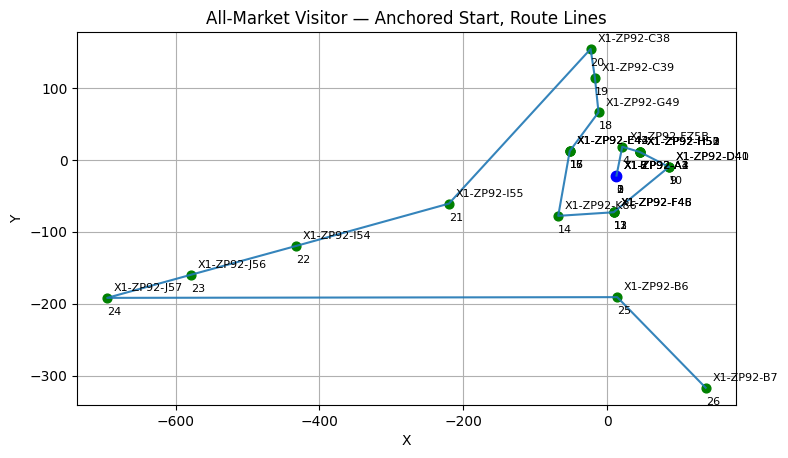

In [4]:
from runtime_support import (
    setup_client_from_env,
    build_fleet_object,
    )

import asyncio

from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi

with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

from core_helpers import (load_initial_fleet_state,
                          init_world_state,
                          load_initial_waypoint_state,
                          get_wps_by_trait,
                          all_market_visitor,
                          api_get_ship_nav,
                          plot_route_svg,
                          market_to_db,
                          patrol_markets
                          )


#-------- write fleet activity and fleet specifications to db -------------
state = await load_initial_fleet_state(fleet_api)

#-------- write waypoint reference data and traits specifications to db and local objects -------------
wp_refs, wp_traits = await load_initial_waypoint_state(agents_api, systems_api)
print(f"Persisted {len(wp_refs)} waypoint refs and {len(wp_traits)} traits.")

# --------- create locally persisting objects for fleet and world states -------------------
ships_activity_obj = await build_fleet_object(fleet_api)
world_state = await init_world_state(fleet_api, agents_api, systems_api)

# --------- define ship roles -----------

# Extract symbol for a given role
def get_symbol_by_role(ships_dict, role):
    for ship in ships_dict.values():
        if ship.role == role:
            return ship.symbol
    return None

# manually assign ship names by role
command_ship = get_symbol_by_role(state.specs, "COMMAND")
satellite = get_symbol_by_role(state.specs, "SATELLITE")


# ---------- get market waypoints from world state ----------
# all traits of every waypoint
traits_list = world_state.traits.by_wp
# selecting MARKETPLACE trait-bearing waypoints only
markets_df = await get_wps_by_trait(traits_list, "MARKETPLACE")

# from selected ships' starting waypoint, draw a route that will visit all market waypoints

nav_resp = await api_get_ship_nav(fleet_api, command_ship)

print(nav_resp.waypoint_symbol)
if __name__ == "__main__":
    
    start = nav_resp.waypoint_symbol

    route = all_market_visitor(
        markets_df= markets_df,
        start_waypoint=start,
        return_to_start=False,   # set True to draw a loop back to start
        improve_2opt=True,
        fix_start_anchor=True,   # keep chosen start as first
    )

    print(route)
    print("Total travel distance:", route["cumulative_distance"].iloc[-1])

    plot_route_svg(
        markets_df=markets_df,
        route_df=route,
        start_waypoint=start,
        svg_path="markets_route.svg",
    )
# ---------- run ----------
async def main():
    patroller = asyncio.create_task(patrol_markets(command_ship, route))
    #patroller2 = asyncio.create_task(patrol_markets(command_ship, route))
    await asyncio.gather(patroller)

await main()
